# Module 08 — Metrics, Calibration and Thresholds

A classifier does not make decisions. It produces a **score**. Turning that
score into a decision — approve or decline, investigate or ignore, call or
don't — requires a threshold, and choosing a threshold requires knowing what
each kind of error costs.

Almost every "the model didn't deliver value" post-mortem traces back to this
module rather than to the model. The score was fine. The threshold was 0.5
because that is the default, and 0.5 is only correct when a false positive and
a false negative cost the same amount, which is essentially never.

### Learning objectives

1. Choose a metric from the decision being made, not from habit.
2. Explain why ROC AUC flatters an imbalanced problem and PR AUC does not.
3. Separate **ranking quality** from **calibration** — and know which of your
   downstream uses needs which.
4. Set a threshold from a cost matrix, and use `TunedThresholdClassifierCV`.
5. Compare the three imbalance levers — `class_weight`, resampling, threshold
   tuning — and know which is mostly theatre.
6. Write a custom scorer that encodes the actual business objective.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name in {"notebooks", "solutions"} else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from skmastery import load_card_fraud, load_credit_risk, plot_calibration, plot_pr_roc, set_plot_style

set_plot_style()
pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 40)
rng = np.random.default_rng(0)

In [2]:
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

credit = load_credit_risk()
y = credit["default"]
X = credit.drop(columns=["default", "application_id", "collections_flag", "application_month"])

prep = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median", add_indicator=True)), ("sc", StandardScaler())]),
     make_column_selector(dtype_include=[np.number, "bool"])),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="constant", fill_value="__missing__")),
                      ("ohe", OneHotEncoder(handle_unknown="ignore", min_frequency=30, sparse_output=False))]),
     make_column_selector(dtype_include=["object", "string", "category"])),
])

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)
model = Pipeline([("prep", prep), ("clf", LogisticRegression(max_iter=4000, C=0.3))]).fit(X_tr, y_tr)
scores = model.predict_proba(X_te)[:, 1]

print(f"test set: {len(y_te):,} rows, {y_te.mean():.2%} default rate")

test set: 3,600 rows, 13.25% default rate


## 1. The accuracy trap

Start with the number everyone reaches for first, and the model that beats it.

In [3]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, precision_score, recall_score

always_no = DummyClassifier(strategy="most_frequent").fit(X_tr, y_tr)

comparison = pd.DataFrame([
    {"model": "our logistic regression", "accuracy": accuracy_score(y_te, model.predict(X_te)),
     "precision": precision_score(y_te, model.predict(X_te), zero_division=0),
     "recall": recall_score(y_te, model.predict(X_te)),
     "balanced_acc": balanced_accuracy_score(y_te, model.predict(X_te))},
    {"model": "'nobody ever defaults'", "accuracy": accuracy_score(y_te, always_no.predict(X_te)),
     "precision": precision_score(y_te, always_no.predict(X_te), zero_division=0),
     "recall": recall_score(y_te, always_no.predict(X_te)),
     "balanced_acc": balanced_accuracy_score(y_te, always_no.predict(X_te))},
]).set_index("model").round(4)
comparison

,accuracy,precision,recall,balanced_acc
model,,,,
our logistic regression,0.8808,0.6846,0.1866,0.5867
'nobody ever defaults',0.8675,0.0000,0.0000,0.5000


The model that never predicts a default is *more accurate* than the real
model, and it is worth nothing. This is not a subtle statistical point — it is
the reason accuracy should almost never appear in a business report on an
imbalanced problem.

Notice also the model's recall: at the default 0.5 threshold it catches almost
no defaults at all. It is not a bad model; it is a good model being asked the
wrong question. Section 4 fixes it, and the fix costs nothing.

## 2. The metric selection table

| Metric | Range | Answers | Use when | Blind to |
|---|---|---|---|---|
| `accuracy` | 0–1 | fraction correct | balanced classes, equal costs | imbalance — completely |
| `balanced_accuracy` | 0–1 | mean of per-class recall | imbalanced, equal class importance | prevalence |
| `precision` | 0–1 | of those flagged, how many were right | false positives are expensive | everything you missed |
| `recall` | 0–1 | of the real positives, how many did we catch | false negatives are expensive | false alarm volume |
| `f1` | 0–1 | harmonic mean of the two | a single number, roughly equal costs | true negatives; asymmetric costs |
| `roc_auc` | 0.5–1 | probability a random positive outranks a random negative | ranking quality; comparing models | prevalence, calibration |
| `average_precision` | ~base–1 | area under precision-recall | **imbalanced ranking** | calibration |
| `neg_log_loss` | 0–∞ | probability quality (proper scoring rule) | you need probabilities | — |
| `neg_brier_score` | 0–1 | mean squared probability error | calibration + discrimination | — |
| `matthews_corrcoef` | −1–1 | correlation of prediction and truth | one balanced number on imbalanced data | — |

**The decision procedure**, in order:

1. Do you need a *probability* (pricing, expected loss, downstream arithmetic)?
   → log loss or Brier, and check calibration.
2. Do you need a *ranking* (a fixed-capacity review queue)? → average precision
   if imbalanced, ROC AUC if not.
3. Do you need a *decision* with known costs? → build the cost matrix, optimise
   expected cost directly. Section 4.

## 3. ROC vs precision-recall on an imbalanced problem

The single most important picture in this module.

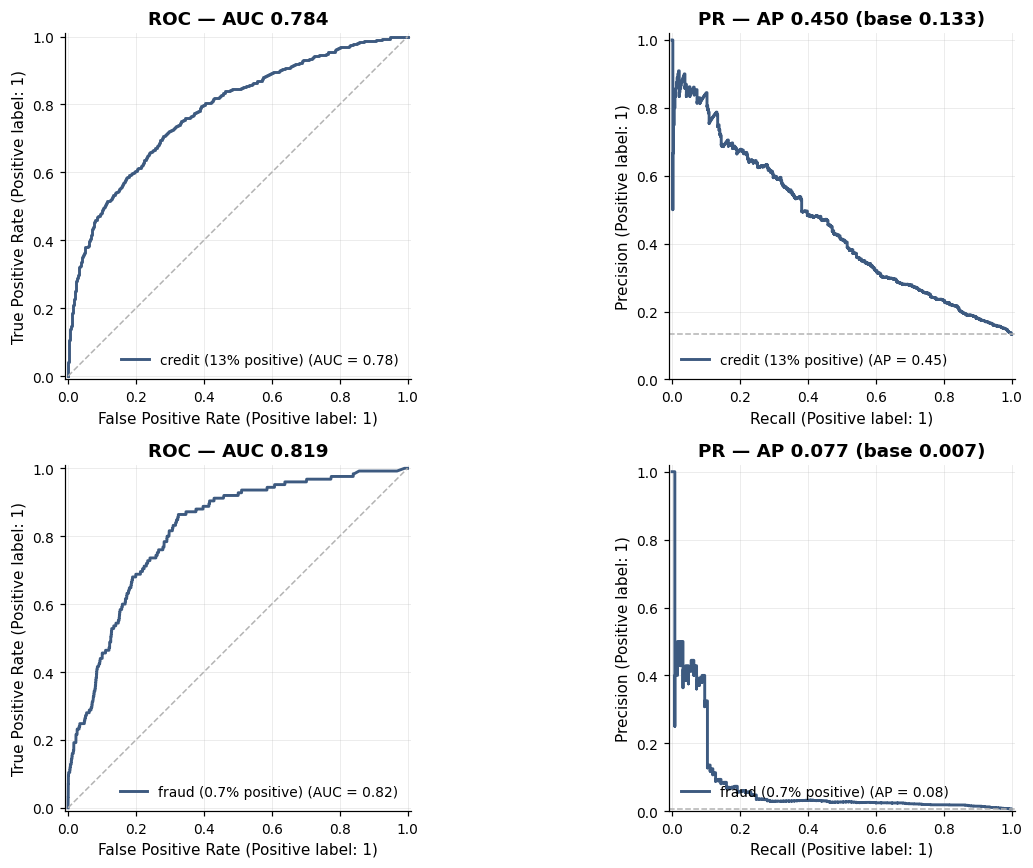

In [4]:
fraud = load_card_fraud()
f_feat = fraud.drop(columns=["is_fraud", "timestamp", "card_id"])
for c in f_feat.select_dtypes(include=["object", "string"]).columns:
    f_feat[c] = f_feat[c].astype("category")
f_y = fraud["is_fraud"]

Xf_tr, Xf_te, yf_tr, yf_te = train_test_split(f_feat, f_y, test_size=0.3, stratify=f_y, random_state=0)
fraud_model = HistGradientBoostingClassifier(categorical_features="from_dtype", random_state=0, max_iter=250).fit(Xf_tr, yf_tr)
f_scores = fraud_model.predict_proba(Xf_te)[:, 1]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plot_pr_roc(y_te, scores, label="credit (13% positive)", axes=axes[0])
plot_pr_roc(yf_te, f_scores, label="fraud (0.7% positive)", axes=axes[1])
plt.tight_layout()

Read the fraud row. ROC AUC is a respectable-looking number. Average precision
is a fraction of it. **Both are correct**; they answer different questions.

The reason is the denominator. The ROC curve's x-axis is the false-positive
*rate* — false positives divided by the (enormous) number of negatives. With
59,600 negatives, flagging 600 innocent transactions moves the FPR by 0.01,
which barely dents the curve. Precision's denominator is the number of alerts
you actually raised, so those 600 false alarms dominate it — as they do in the
operations centre that has to work the queue.

> 💼 **Consulting lens.** If a fraud, churn, or default model is presented to
> you with only an ROC AUC, ask for precision at the operating point and the
> expected alert volume per day. "AUC 0.93" and "your team of six will
> investigate 4,000 alerts a week to find nine frauds" are both true, and only
> one of them is a business fact.

In [5]:
# The alert-volume view -- the number the operations team actually cares about.
from sklearn.metrics import precision_recall_curve

prec, rec, thr = precision_recall_curve(yf_te, f_scores)
n_daily = len(yf_te) / 180                                    # test set spans ~180 days
operating = pd.DataFrame({
    "threshold": thr,
    "precision": prec[:-1],
    "recall": rec[:-1],
    "alerts_per_day": [(f_scores >= t).sum() / 180 for t in thr],
})
operating = operating[operating.alerts_per_day.between(0.5, 60)]
operating.iloc[:: max(1, len(operating) // 8)].round(3).to_string(index=False)

' threshold  precision  recall  alerts_per_day\n     0.001      0.011   0.944          60.000\n     0.002      0.012   0.936          52.167\n     0.002      0.014   0.912          43.750\n     0.003      0.017   0.872          36.306\n     0.004      0.019   0.784          28.978\n     0.006      0.022   0.696          22.022\n     0.010      0.025   0.560          15.372\n     0.015      0.030   0.336           7.822'

## 4. Thresholds: where the money is

The default 0.5 threshold assumes false positives and false negatives cost the
same. Make the costs explicit and the optimal threshold falls out.

For our credit book, plausible economics:

- **Approve a loan that defaults** (false negative): lose ~40% of a £15,000
  principal ≈ **£6,000**.
- **Decline a loan that would have repaid** (false positive): forgo the margin,
  roughly **£450**.

The cost asymmetry is about 13:1. The threshold should be nowhere near 0.5.

cost at threshold 0.50 : £652 per application
cost at threshold 0.089 : £311 per application
saving                 : £341 per application (52.3%)


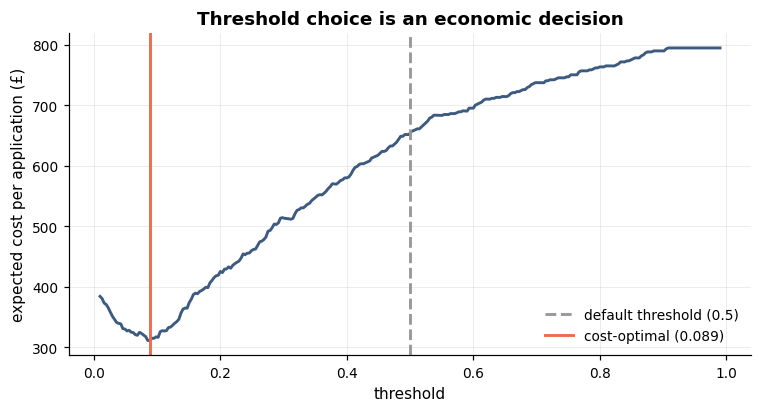

In [6]:
from sklearn.metrics import confusion_matrix

COST_FN = 6_000.0     # approved, then defaulted
COST_FP = 450.0       # declined a good customer


def expected_cost(y_true, y_score, threshold):
    tn, fp, fn, tp = confusion_matrix(y_true, (y_score >= threshold).astype(int), labels=[0, 1]).ravel()
    return (fn * COST_FN + fp * COST_FP) / len(y_true)


thresholds = np.linspace(0.01, 0.99, 300)
costs = np.array([expected_cost(y_te, scores, t) for t in thresholds])
best_t = thresholds[costs.argmin()]

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.plot(thresholds, costs)
ax.axvline(0.5, ls="--", color="0.6", label="default threshold (0.5)")
ax.axvline(best_t, color="#ee6c4d", label=f"cost-optimal ({best_t:.3f})")
ax.set(xlabel="threshold", ylabel="expected cost per application (£)", title="Threshold choice is an economic decision")
ax.legend()

print(f"cost at threshold 0.50 : £{expected_cost(y_te, scores, 0.5):,.0f} per application")
print(f"cost at threshold {best_t:.3f} : £{costs.min():,.0f} per application")
print(f"saving                 : £{expected_cost(y_te, scores, 0.5) - costs.min():,.0f} per application "
      f"({1 - costs.min() / expected_cost(y_te, scores, 0.5):.1%})")

Moving one number — no retraining, no new features, no new model — cuts
expected cost by **more than half**. This is routinely the highest-return hour
of work in an entire modelling engagement, and it is routinely skipped.

There is a closed form worth knowing: for a well-calibrated model, the
cost-minimising threshold is

$$ t^* = \frac{C_{FP}}{C_{FP} + C_{FN}} $$

which here is 450 / 6450 ≈ 0.070.

In [7]:
print(f"theoretical optimum for a calibrated model: {COST_FP / (COST_FP + COST_FN):.4f}")
print(f"empirical optimum found above            : {best_t:.4f}")
print("\nThe gap between them is a calibration diagnostic -- see section 5.")

theoretical optimum for a calibrated model: 0.0698
empirical optimum found above            : 0.0887

The gap between them is a calibration diagnostic -- see section 5.


### `TunedThresholdClassifierCV` does this properly

Choosing the threshold on your test set is the same leak as choosing anything
else on your test set. Since 1.5, sklearn has a meta-estimator that tunes the
threshold by cross-validation inside `fit`.

In [8]:
from sklearn.metrics import make_scorer
from sklearn.model_selection import TunedThresholdClassifierCV

def business_gain(y_true, y_pred):
    """Negative expected cost -- higher is better, as scorers require."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return -(fn * COST_FN + fp * COST_FP) / len(y_true)


tuned = TunedThresholdClassifierCV(
    estimator=Pipeline([("prep", prep), ("clf", LogisticRegression(max_iter=4000, C=0.3))]),
    scoring=make_scorer(business_gain),
    cv=5,
    refit=True,
    random_state=0,
).fit(X_tr, y_tr)

print(f"threshold chosen by CV : {tuned.best_threshold_:.4f}")
print(f"cost on the held-out test set: £{-business_gain(y_te, tuned.predict(X_te)):,.0f} per application")
print(f"(the same model at 0.5      : £{expected_cost(y_te, scores, 0.5):,.0f})")

threshold chosen by CV : 0.0609
cost on the held-out test set: £322 per application
(the same model at 0.5      : £652)


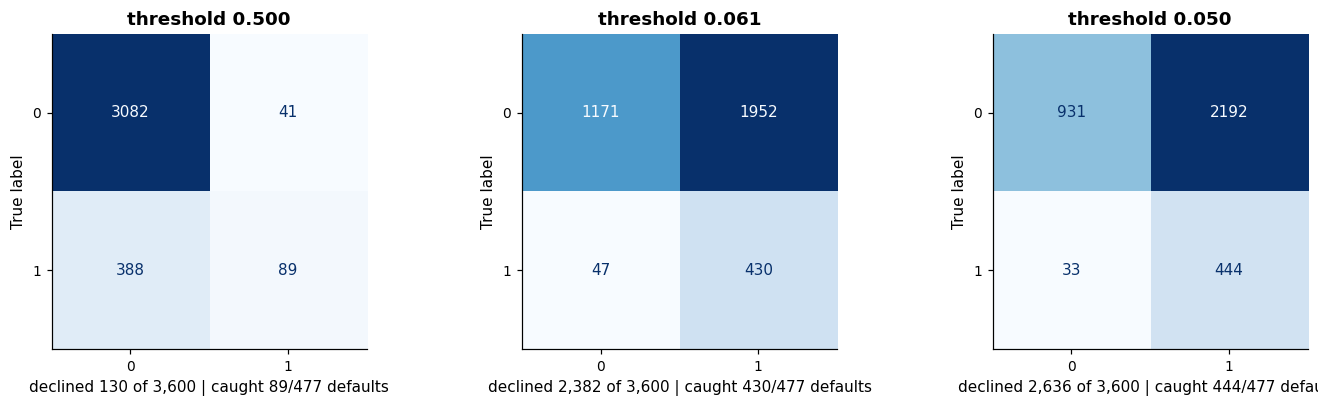

In [9]:
# What the decision actually looks like at each threshold.
from skmastery import plot_confusion

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, t in zip(axes, [0.5, tuned.best_threshold_, 0.05]):
    plot_confusion(y_te, (scores >= t).astype(int), ax=ax, title=f"threshold {t:.3f}")
    tn, fp, fn, tp = confusion_matrix(y_te, (scores >= t).astype(int), labels=[0, 1]).ravel()
    ax.set_xlabel(f"declined {fp + tp:,} of {len(y_te):,} | caught {tp}/{tp + fn} defaults")
plt.tight_layout()

## 5. Calibration: a different property from ranking

**Ranking**: does the model put riskier applicants above safer ones? Measured
by AUC. **Calibration**: when the model says 0.20, do 20% of those applicants
actually default? Measured by a reliability diagram, Brier score or log loss.

These are independent. A model can rank perfectly and be badly calibrated —
squaring every probability leaves AUC untouched and destroys calibration
entirely. You need calibration whenever the *number* is used, not just the
order: expected-loss provisioning, risk-based pricing, capital calculations,
any threshold derived from a cost formula, and any model whose output feeds
another model.

In [10]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score

candidates = {
    "LogisticRegression": Pipeline([("prep", prep), ("clf", LogisticRegression(max_iter=4000, C=0.3))]),
    "RandomForest": Pipeline([("prep", prep), ("clf", RandomForestClassifier(n_estimators=300, min_samples_leaf=5, random_state=0, n_jobs=-1))]),
    "HistGradientBoosting": Pipeline([("prep", prep), ("clf", HistGradientBoostingClassifier(random_state=0, max_iter=300, learning_rate=0.06))]),
    "SVM (uncalibrated)": Pipeline([("prep", prep), ("clf", __import__("sklearn.svm", fromlist=["SVC"]).SVC(probability=True, random_state=0))]),
}

probs, rows = {}, []
for name, est in candidates.items():
    p = est.fit(X_tr, y_tr).predict_proba(X_te)[:, 1]
    probs[name] = p
    rows.append({"model": name,
                 "roc_auc": round(roc_auc_score(y_te, p), 4),
                 "log_loss": round(log_loss(y_te, p), 4),
                 "brier": round(brier_score_loss(y_te, p), 5),
                 "mean_pred": round(p.mean(), 4),
                 "actual_rate": round(y_te.mean(), 4)})
pd.DataFrame(rows).set_index("model")

,roc_auc,log_loss,brier,mean_pred,actual_rate
model,,,,,
LogisticRegression,0.7836,0.3188,0.09332,0.1363,0.1325
RandomForest,0.7761,0.3234,0.09458,0.1379,0.1325
HistGradientBoosting,0.7518,0.3453,0.09850,0.1174,0.1325
SVM (uncalibrated),0.6735,0.3476,0.10020,0.1321,0.1325


<Axes: title={'center': 'Calibration'}, xlabel='mean predicted probability', ylabel='observed frequency'>

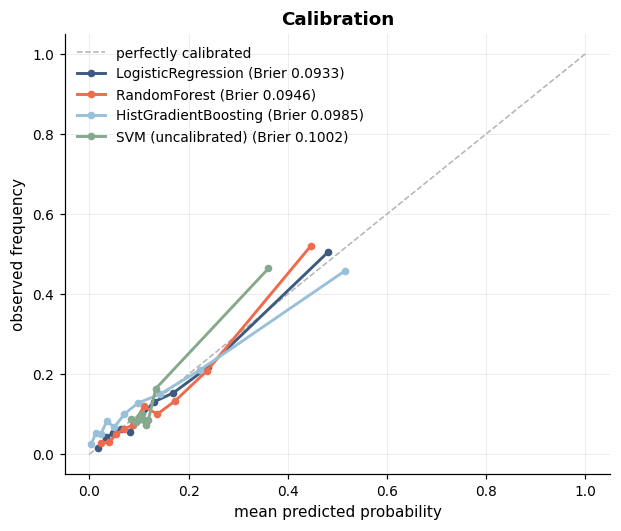

In [11]:
fig, ax = plt.subplots(figsize=(6.4, 5.2))
plot_calibration(y_te, probs, n_bins=10, ax=ax)

The `mean_pred` vs `actual_rate` columns are the cheapest calibration check
there is: **if the average predicted probability does not match the observed
base rate, the model is not calibrated in aggregate**, and any expected-loss
figure computed from it is wrong by that ratio.

At a 13% base rate the aggregate distortion here is mild — every model's mean
prediction is within a point or two of the truth. Hold that thought: in
section 6 you will see the same column on the 0.7% fraud problem, where
resampling moves the mean predicted probability from 0.007 to 0.29 and the
model's probabilities stop referring to anything real at all. **Calibration
damage scales with how far you distort the base rate.**

Two systematic biases worth recognising in the reliability diagram:

- **Random forests** are pulled towards the centre. Each tree votes 0 or 1, and
  averaging many votes rarely yields a value near 0 or 1 — so extreme
  probabilities are compressed.
- **SVMs and boosted models** tend to be over-confident, pushed towards 0 and 1
  by the margin-maximising / exponential-style losses.
- **Logistic regression is calibrated by construction** on the training
  distribution, because log loss is a proper scoring rule and the model is
  fitting it directly. This is a genuinely underrated argument for logistic
  regression in pricing and provisioning work.

In [12]:
# Fixing it: CalibratedClassifierCV wraps a model and learns a mapping from its
# scores to calibrated probabilities, using cross-validation so it does not leak.
base_rf = Pipeline([("prep", prep), ("clf", RandomForestClassifier(n_estimators=300, min_samples_leaf=5, random_state=0, n_jobs=-1))])

calibrated = {}
for method in ["sigmoid", "isotonic"]:
    cal = CalibratedClassifierCV(base_rf, method=method, cv=5).fit(X_tr, y_tr)
    calibrated[f"RF + {method}"] = cal.predict_proba(X_te)[:, 1]
calibrated["RF (raw)"] = probs["RandomForest"]

cal_table = pd.DataFrame([
    {"model": k, "roc_auc": round(roc_auc_score(y_te, v), 4),
     "brier": round(brier_score_loss(y_te, v), 5), "log_loss": round(log_loss(y_te, v), 4),
     "mean_pred": round(v.mean(), 4)}
    for k, v in calibrated.items()
]).set_index("model")
print(f"(observed base rate: {y_te.mean():.4f})")
cal_table

(observed base rate: 0.1325)


,roc_auc,brier,log_loss,mean_pred
model,,,,
RF + sigmoid,0.7733,0.09447,0.3246,0.1345
RF + isotonic,0.7712,0.09452,0.3235,0.1350
RF (raw),0.7761,0.09458,0.3234,0.1379


<Axes: title={'center': 'Calibration'}, xlabel='mean predicted probability', ylabel='observed frequency'>

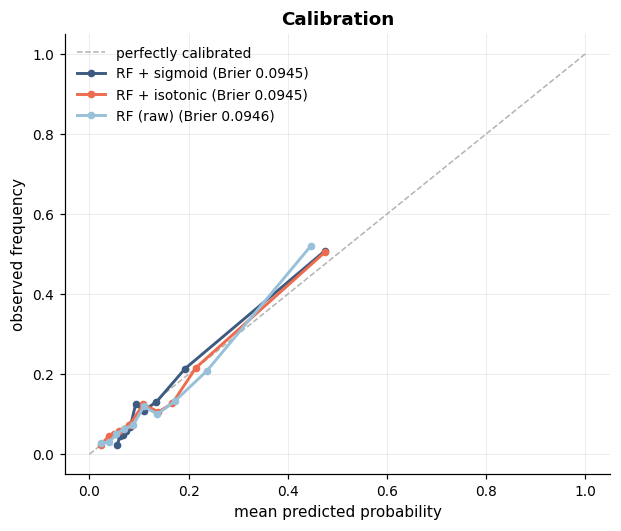

In [13]:
fig, ax = plt.subplots(figsize=(6.4, 5.2))
plot_calibration(y_te, calibrated, n_bins=10, ax=ax)

### Choosing a calibration method

| Method | Fits | Needs | Risk |
|---|---|---|---|
| `sigmoid` (Platt) | a 2-parameter logistic curve | ~hundreds of samples | can't fix non-sigmoidal distortion |
| `isotonic` | any monotone step function | ~1,000+ samples | overfits on small data; output is piecewise-constant |
| `temperature` (new in 1.8) | a single scaling parameter on the logits | very little data | multiclass-friendly; least flexible |

Note what calibration does **not** do: it is a monotone transform of the
scores, so **ROC AUC is unchanged**. Calibration cannot make a model better at
ranking. It makes its numbers mean what they say.

`temperature` is the 1.8 addition and is the right default for multiclass:
where `sigmoid` and `isotonic` fit a separate one-vs-rest calibrator per class,
temperature scaling fits one parameter for all of them, so it needs far less
data and cannot reorder the classes.

## 6. The three imbalance levers

Faced with 0.7% positives, people reach for SMOTE. It is usually the least
effective of the three available moves, and the only one that changes the data.

In [14]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import average_precision_score

def evaluate(name, est, threshold=0.5):
    est.fit(Xf_tr, yf_tr)
    p = est.predict_proba(Xf_te)[:, 1]
    pred = (p >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(yf_te, pred, labels=[0, 1]).ravel()
    return {
        "approach": name,
        "roc_auc": round(roc_auc_score(yf_te, p), 4),
        "avg_prec": round(average_precision_score(yf_te, p), 4),
        "brier": round(brier_score_loss(yf_te, p), 6),
        "mean_pred": round(p.mean(), 5),
        "recall@thr": round(tp / max(tp + fn, 1), 3),
        "precision@thr": round(tp / max(tp + fp, 1), 3),
    }


def hgb(**kw):
    return HistGradientBoostingClassifier(categorical_features="from_dtype", random_state=0, max_iter=250, **kw)


ohe_num = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                              make_column_selector(dtype_include=["object", "string", "category"]))],
                            remainder="passthrough")

results = [
    evaluate("baseline (threshold 0.5)", hgb()),
    evaluate("class_weight='balanced'", hgb(class_weight="balanced")),
    evaluate("SMOTE", ImbPipeline([("prep", ohe_num), ("smote", SMOTE(random_state=0)), ("clf", HistGradientBoostingClassifier(random_state=0, max_iter=250))])),
    evaluate("random under-sampling", ImbPipeline([("prep", ohe_num), ("rus", RandomUnderSampler(random_state=0)), ("clf", HistGradientBoostingClassifier(random_state=0, max_iter=250))])),
]
# Same baseline model, threshold moved to the 99th percentile of its scores.
base_est = hgb().fit(Xf_tr, yf_tr)
p_base = base_est.predict_proba(Xf_te)[:, 1]
t99 = np.quantile(p_base, 0.99)
results.append(evaluate(f"baseline + threshold @ p99", hgb(), threshold=t99))

pd.DataFrame(results).set_index("approach")

,roc_auc,avg_prec,brier,mean_pred,recall@thr,precision@thr
approach,,,,,,
baseline (threshold 0.5),0.8186,0.0771,0.007008,0.00731,0.096,0.400
class_weight='balanced',0.8372,0.0991,0.101003,0.23003,0.688,0.030
SMOTE,0.8255,0.0970,0.006729,0.00818,0.032,0.364
random under-sampling,0.8210,0.0434,0.221855,0.29070,0.776,0.019
baseline + threshold @ p99,0.8186,0.0771,0.007008,0.00731,0.128,0.089


### What that table says

- **Ranking barely improves, and can collapse.** `class_weight` and SMOTE lift
  average precision from 0.077 to ~0.10 — a real but modest gain, and one you
  should check against the noise floor before believing. Random under-sampling
  *halves* it, to 0.043: throwing away 99% of the negatives threw away most of
  what the model needed to learn the boundary. Ranking quality is what
  determines what the operations team can achieve, and none of these levers
  transformed it.
- **Calibration is destroyed.** `mean_pred` goes from 0.0073 (the truth is
  0.0069) to 0.23 under `class_weight` and 0.29 under under-sampling — a
  factor of forty. Brier degrades by the same order. These models' outputs are
  no longer probabilities of anything; every expected-loss figure computed from
  them is wrong, and nothing raises an error.
- **Look at the last two rows together.** The baseline model at threshold 0.5
  catches 9.6% of fraud at 40% precision. The *same model*, threshold moved to
  its 99th percentile, catches 12.8% at 8.9% precision. One number, no
  retraining, and the entire operating point moves — while the probabilities
  stay honest.

**The rule:** imbalance is a *decision-threshold* problem, not a *data*
problem. Fix it at the threshold. Reach for `class_weight` when the model
genuinely underfits the minority (very few positives in absolute terms — say,
under a few hundred), and re-calibrate afterwards if you need probabilities.
Reach for resampling last, and mostly when you have a computational reason
(under-sampling a 50-million-row negative class to make training tractable).

## 7. Custom scorers

`make_scorer` turns any function into something `cross_val_score`,
`GridSearchCV` and `TunedThresholdClassifierCV` can optimise. This is how the
business objective gets into the model-selection loop rather than being
applied as an afterthought.

In [15]:
from sklearn.metrics import make_scorer
from sklearn.model_selection import cross_validate

def profit_per_application(y_true, y_score, cost_fn=COST_FN, cost_fp=COST_FP, margin=450.0):
    """Expected profit at the cost-optimal threshold for THIS model.

    Note it takes a *score*, so it needs `response_method="predict_proba"`.
    """
    t_star = cost_fp / (cost_fp + cost_fn)
    pred = (y_score >= t_star).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return (tn * margin - fn * cost_fn - fp * cost_fp) / len(y_true)


profit_scorer = make_scorer(profit_per_application, response_method="predict_proba", greater_is_better=True)

res = cross_validate(
    Pipeline([("prep", prep), ("clf", LogisticRegression(max_iter=4000, C=0.3))]),
    X, y, cv=StratifiedKFold(5, shuffle=True, random_state=0),
    scoring={"auc": "roc_auc", "ap": "average_precision", "profit": profit_scorer},
    n_jobs=-1,
)
pd.DataFrame({k: v for k, v in res.items() if k.startswith("test_")}).agg(["mean", "std"]).round(4)

,test_auc,test_ap,test_profit
mean,0.7744,0.4263,-146.9375
std,0.0115,0.0143,17.5222


In [16]:
# And now the point: tune the model FOR profit, not for AUC, and see if the
# choice differs.
from sklearn.model_selection import GridSearchCV

search = GridSearchCV(
    Pipeline([("prep", prep), ("clf", LogisticRegression(max_iter=4000))]),
    {"clf__C": [0.01, 0.1, 1.0, 10.0], "clf__class_weight": [None, "balanced"]},
    cv=StratifiedKFold(5, shuffle=True, random_state=0),
    scoring={"auc": "roc_auc", "profit": profit_scorer},
    refit="profit", n_jobs=-1,
).fit(X, y)

out = pd.DataFrame(search.cv_results_)[["param_clf__C", "param_clf__class_weight", "mean_test_auc", "mean_test_profit"]].round(4)
out["rank_by_auc"] = out.mean_test_auc.rank(ascending=False).astype(int)
out["rank_by_profit"] = out.mean_test_profit.rank(ascending=False).astype(int)
out.sort_values("rank_by_profit")

,param_clf__C,param_clf__class_weight,mean_test_auc,mean_test_profit,rank_by_auc,rank_by_profit
6,10.00,NaN,0.7741,-145.9875,5,1
4,1.00,NaN,0.7742,-146.5125,4,2
2,0.10,NaN,0.7746,-148.7625,3,3
0,0.01,NaN,0.7761,-149.7375,1,4
5,1.00,balanced,0.7735,-375.4875,7,5
7,10.00,balanced,0.7735,-375.5625,7,6
3,0.10,balanced,0.7738,-376.0875,6,7
1,0.01,balanced,0.7751,-378.9125,2,8


**They disagree, and instructively.** `C=0.01` has the *highest* AUC of the
eight candidates and ranks fourth on profit. Worse, `class_weight="balanced"`
occupies second place on AUC and last place on profit — the four balanced
variants are separated from the four unbalanced ones by roughly £230 per
application, a gap the AUC column renders as a difference in the third decimal
place.

The mechanism is section 5: `class_weight` distorts the predicted
probabilities, the profit scorer applies a threshold derived from a cost ratio,
and a threshold derived for calibrated probabilities is simply wrong when
applied to uncalibrated ones. An AUC-only comparison is blind to this by
construction, because AUC is invariant to exactly the distortion that causes
it.

If `rank_by_auc` and `rank_by_profit` disagree, optimising AUC was selecting
the wrong model — and you would never have known, because the AUC table looked
fine.

## 8. Multiclass averaging

With more than two classes, every metric needs an averaging rule, and the
choice changes the number a lot on imbalanced problems.

In [17]:
from skmastery import load_support_tickets
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, f1_score

tickets = load_support_tickets()
t_tr, t_te, ty_tr, ty_te = train_test_split(tickets["text"], tickets["category"], test_size=0.3, stratify=tickets["category"], random_state=0)
tmodel = Pipeline([("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2)), ("clf", LogisticRegression(max_iter=2000))]).fit(t_tr, ty_tr)
ty_pred = tmodel.predict(t_te)

print(classification_report(ty_te, ty_pred, digits=3))

                 precision    recall  f1-score   support

 account_access      0.818     0.854     0.836       343
        billing      0.771     0.888     0.825       402
      complaint      0.944     0.782     0.856       193
  fraud_dispute      0.945     0.779     0.854       244
general_enquiry      0.831     0.875     0.853       344
 loan_servicing      0.871     0.814     0.842       274

       accuracy                          0.842      1800
      macro avg      0.864     0.832     0.844      1800
   weighted avg      0.849     0.842     0.842      1800



In [18]:
pd.Series({
    "micro (= accuracy here)": f1_score(ty_te, ty_pred, average="micro"),
    "macro (unweighted class mean)": f1_score(ty_te, ty_pred, average="macro"),
    "weighted (by support)": f1_score(ty_te, ty_pred, average="weighted"),
}, name="f1").round(4).to_frame()

,f1
micro (= accuracy here),0.8417
macro (unweighted class mean),0.8442
weighted (by support),0.8422


- **micro** pools all decisions, so large classes dominate. For single-label
  multiclass it equals accuracy.
- **macro** averages the per-class scores equally, so a rare class counts as
  much as a common one. **Use this when every class matters equally** — it is
  the honest choice when you care about the small classes.
- **weighted** averages by class frequency. It is the most flattering and the
  least informative; it can hide total failure on a rare class.

Report macro when the rare classes matter, and always show the per-class
breakdown alongside.

## 9. Regression metrics, briefly

| Metric | Units | Penalises | Use when |
|---|---|---|---|
| `MAE` | target units | linearly | you want the median-ish error; outliers should not dominate |
| `RMSE` | target units | quadratically | large errors are disproportionately bad |
| `MAPE` | % | relative error | scale varies wildly; **breaks near zero** |
| `R²` | unitless | — | comparing across datasets; **misleading on non-linear or grouped data** |
| `pinball` | target units | asymmetrically | you are predicting a quantile, not a mean |
| `mean_poisson/gamma/tweedie_deviance` | — | by the assumed distribution | counts, costs, non-negative skewed targets |

The trap worth naming: **MAE and RMSE can rank two models differently**, and
neither is "right". If you optimise squared error you are choosing to predict
a conditional mean; if you optimise absolute error you are choosing the
conditional median. On a skewed target those are very different numbers, and
which one the business wants is a question, not a default.

In [19]:
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

hous = fetch_california_housing(as_frame=True)
Xh_tr, Xh_te, yh_tr, yh_te = train_test_split(hous.data, hous.target, random_state=0)

reg_rows = []
for name, loss in [("squared_error", "squared_error"), ("absolute_error", "absolute_error")]:
    m = HistGradientBoostingRegressor(loss=loss, random_state=0, max_iter=300).fit(Xh_tr, yh_tr)
    p = m.predict(Xh_te)
    reg_rows.append({"trained to minimise": name,
                     "MAE": round(mean_absolute_error(yh_te, p), 4),
                     "RMSE": round(mean_squared_error(yh_te, p) ** 0.5, 4),
                     "R2": round(r2_score(yh_te, p), 4)})
pd.DataFrame(reg_rows).set_index("trained to minimise")

,MAE,RMSE,R2
trained to minimise,,,
squared_error,0.2968,0.4505,0.8464
absolute_error,0.2986,0.4729,0.8308


Each model wins on the metric it was trained for. That is not a coincidence
and it is not cheating — it is the point. **Train on the loss you will be
judged by.**

---
## Exercises

### Exercise 8.1 — Build the cost curve for the fraud problem

Assume: a missed fraud costs the average fraudulent transaction amount; an
investigated non-fraud costs £12 of analyst time; and the team can work at
most 40 alerts per day.

1. Find the cost-optimal threshold ignoring the capacity constraint.
2. Find the best achievable outcome *subject to* ≤40 alerts/day.
3. Quantify what the capacity constraint costs the business per year, and what
   an extra analyst would be worth.

Present it as the one-slide summary you would take to an operations director.

In [20]:
# Your code here.

### Exercise 8.2 — Break calibration without touching AUC

Take a well-calibrated logistic regression on the credit data and apply three
monotone transforms to its probabilities: `p**2`, `sqrt(p)`, and
`1/(1+exp(-3*logit(p)))`. For each, report ROC AUC, Brier, log loss, mean
prediction, and the cost at the theoretical optimal threshold.

Confirm AUC is *identical* in all cases. Then explain, in the terms a risk
committee would use, why AUC is insufficient as a sole model-quality metric
for provisioning.

In [21]:
# Your code here.

### Exercise 8.3 — Calibration under drift

Train on credit applications before 2023-07 and score everything after. Compute
monthly: ROC AUC, Brier, mean predicted probability, and observed default rate.

1. Which degrades first — ranking or calibration?
2. Fit a `CalibratedClassifierCV` on a small recent window and re-score. How
   much of the damage does re-calibration repair, and how much needs a full
   retrain?
3. Design a monitoring rule that would have fired an alert. State its
   threshold and its expected false-alarm rate.

In [22]:
# Your code here.

### Exercise 8.4 — The imbalance levers, properly measured

Extend section 6 into a full factorial: {no resampling, class_weight, SMOTE,
SMOTEENN, random under-sampling} × {raw, sigmoid-calibrated,
isotonic-calibrated} × {threshold 0.5, cost-optimal threshold}.

Score each on average precision, Brier, and expected cost. Use repeated CV so
you can tell real differences from noise. Then write the half-page
recommendation, and be explicit about which of the fifteen combinations you
would actually put in production and why.

In [23]:
# Your code here.

### Exercise 8.5 — A scorer for a capacity-constrained queue

Write `precision_at_k(k)` — a scorer factory returning precision among the top
*k* scored rows, which is what a fixed-size review queue actually delivers.

Use it to tune a fraud model with `GridSearchCV(scoring=precision_at_k(200))`
and compare the selected model to one tuned on `average_precision`. Do they
choose the same hyperparameters? Then plot precision-at-k against k for both,
and say at which queue sizes the choice matters.

In [24]:
# Your code here.

---
## Takeaways

- **Accuracy is meaningless on imbalanced data.** A model that predicts "no"
  forever will beat your real model.
- ROC AUC measures ranking and is insensitive to prevalence; **average
  precision** is the honest ranking metric when positives are rare.
- **Ranking and calibration are independent properties.** You need calibration
  whenever the number itself is used — pricing, provisioning, expected loss,
  any cost-derived threshold.
- The cost-optimal threshold for a calibrated model is
  `C_FP / (C_FP + C_FN)`. Moving to it is often the single highest-return
  change available, and it needs no retraining.
- Use `TunedThresholdClassifierCV` so the threshold is chosen by
  cross-validation rather than on your test set.
- **Imbalance is a threshold problem, not a data problem.** Resampling mostly
  destroys calibration without improving ranking.
- `make_scorer` puts the business objective inside the selection loop. If
  ranking by AUC and ranking by profit disagree, AUC was choosing the wrong
  model.

**Next:** Module 09 — unsupervised learning, where there is no metric to
argue about and that turns out to be harder, not easier.